In [17]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
Datos = pd.read_excel("../Data/Pharmacy_data.xlsx", sheet_name=None)
for nombre, df in Datos.items():
    print(nombre, df.shape)

FactSales (62139, 9)
DimDate (731, 7)
DimPharmacy (120, 10)
DimProduct (220, 11)


In [4]:
fact = Datos["FactSales"]
fecha = Datos["DimDate"]
farmacia = Datos["DimPharmacy"]
producto = Datos["DimProduct"]

In [5]:
for nombre, df in Datos.items():
    print(f"\n=== {nombre} ===")
    display(df.head())
    print(df.dtypes)
    print("Filas:", df.shape[0], "| Columnas:", df.shape[1])


=== FactSales ===


,SalesID,DateKey,PharmacyID,ProductID,UnitsSold,RevenueEUR,CostEUR,MarginEUR,PromoFlag
0,S0000001,20240101,PH0002,PR0099,5,128.08,87.55,40.53,No
1,S0000002,20240101,PH0004,PR0156,4,51.89,34.32,17.57,No
2,S0000003,20240101,PH0007,PR0004,20,317.73,199.53,118.20,No
3,S0000004,20240101,PH0009,PR0075,6,90.34,67.49,22.85,No
4,S0000005,20240101,PH0010,PR0154,2,160.21,124.99,35.22,Yes


SalesID           str
DateKey         int64
PharmacyID        str
ProductID         str
UnitsSold       int64
RevenueEUR    float64
CostEUR       float64
MarginEUR     float64
PromoFlag         str
dtype: object
Filas: 62139 | Columnas: 9

=== DimDate ===


,DateKey,Date,Year,Quarter,MonthNumber,MonthName,YearMonth
0,20240101,2024-01-01,2024,1,1,January,2024-01
1,20240102,2024-01-02,2024,1,1,January,2024-01
2,20240103,2024-01-03,2024,1,1,January,2024-01
3,20240104,2024-01-04,2024,1,1,January,2024-01
4,20240105,2024-01-05,2024,1,1,January,2024-01


DateKey                 int64
Date           datetime64[us]
Year                    int64
Quarter                 int64
MonthNumber             int64
MonthName                 str
YearMonth                 str
dtype: object
Filas: 731 | Columnas: 7

=== DimPharmacy ===


,PharmacyID,PharmacyName,Country,Region,City,PharmacyType,OpenDate,StoreSizeBand,Latitude,Longitude
0,PH0001,Naples HealthPoint #001,Italy,Campania,Naples,Suburban,2025-04-03,M,40.839137,14.279288
1,PH0002,Innsbruck HealthPoint #002,Austria,Tyrol,Innsbruck,Urban,2011-12-21,M,47.254915,11.410136
2,PH0003,Barcelona HealthPoint #003,Spain,Catalonia,Barcelona,Urban,2025-04-20,M,41.386090,2.170678
3,PH0004,Katowice HealthPoint #004,Poland,Silesian,Katowice,Suburban,2018-07-18,L,50.260198,19.043129
4,PH0005,Poznań HealthPoint #005,Poland,Greater Poland,Poznań,Urban,2021-07-12,S,52.408932,16.920617


PharmacyID           str
PharmacyName         str
Country              str
Region               str
City                 str
PharmacyType         str
OpenDate             str
StoreSizeBand        str
Latitude         float64
Longitude        float64
dtype: object
Filas: 120 | Columnas: 10

=== DimProduct ===


,ProductID,ProductName,Category,Brand,IsGeneric,PackSize,ListPriceEUR,StandardCostEUR,LaunchDate,IsDiscontinued,DiscontinuedDate
0,PR0001,CareEquip Glucose Test Strips Compact,Medical Devices,CareEquip,No,1 unit,10.14,8.19,2018-04-09,No,NaN
1,PR0002,Medica Nasal Spray 100 mg,OTC,Medica,No,200 ml,7.03,5.52,2015-08-21,No,NaN
2,PR0003,VitaCare Vitamin C 100 mg,OTC,VitaCare,No,30 tablets,13.42,10.69,2022-11-22,No,NaN
3,PR0004,DermaSoft Shampoo Repair,Personal Care,DermaSoft,No,100 ml,15.13,8.83,2018-01-10,No,NaN
4,PR0005,CleanWave Moisturizer Sensitive,Personal Care,CleanWave,No,250 ml,14.29,10.56,2025-08-11,No,NaN


ProductID               str
ProductName             str
Category                str
Brand                   str
IsGeneric               str
PackSize                str
ListPriceEUR        float64
StandardCostEUR     float64
LaunchDate              str
IsDiscontinued          str
DiscontinuedDate        str
dtype: object
Filas: 220 | Columnas: 11


In [6]:
for nombre, df in Datos.items():
    print(f"\n=== {nombre} ===")
    print("Nulos por columna:\n", df.isna().sum()[df.isna().sum() > 0])
    print("Filas duplicadas:", df.duplicated().sum())


=== FactSales ===
Nulos por columna:
 Series([], dtype: int64)
Filas duplicadas: 0

=== DimDate ===
Nulos por columna:
 Series([], dtype: int64)
Filas duplicadas: 0

=== DimPharmacy ===
Nulos por columna:
 Series([], dtype: int64)
Filas duplicadas: 0

=== DimProduct ===
Nulos por columna:
 DiscontinuedDate    185
dtype: int64
Filas duplicadas: 0


In [9]:
display(fact.describe())
for nombre, df in Datos.items():
    cat = df.select_dtypes(include=["object", "str"])
    for col in cat.columns:
        print(f"\n{nombre} · {col}: {cat[col].nunique()} valores")
        print(cat[col].value_counts().head(10))

,DateKey,UnitsSold,RevenueEUR,CostEUR,MarginEUR
count,6.213900e+04,62139.000000,62139.000000,62139.000000,62139.000000
mean,2.024579e+07,7.174126,138.946190,99.982881,38.963309
std,5.014700e+03,4.873395,124.574712,93.611370,33.972445
min,2.024010e+07,1.000000,1.610000,1.100000,0.440000
25%,2.024071e+07,3.000000,55.250000,39.330000,15.140000
50%,2.025011e+07,6.000000,102.750000,72.220000,28.990000
75%,2.025071e+07,10.000000,181.350000,128.680000,51.990000
max,2.025123e+07,25.000000,1036.280000,834.420000,295.310000



FactSales · SalesID: 62139 valores
SalesID
S0000001    1
S0000002    1
S0000003    1
S0000004    1
S0000005    1
S0000006    1
S0000007    1
S0000008    1
S0000009    1
S0000010    1
Name: count, dtype: int64

FactSales · PharmacyID: 120 valores
PharmacyID
PH0095    919
PH0023    896
PH0018    888
PH0078    887
PH0058    881
PH0051    865
PH0056    862
PH0010    855
PH0085    855
PH0073    844
Name: count, dtype: int64

FactSales · ProductID: 220 valores
ProductID
PR0063    379
PR0178    378
PR0200    376
PR0054    376
PR0207    376
PR0079    371
PR0174    370
PR0007    369
PR0078    366
PR0093    362
Name: count, dtype: int64

FactSales · PromoFlag: 2 valores
PromoFlag
No     54708
Yes     7431
Name: count, dtype: int64

DimDate · MonthName: 12 valores
MonthName
January      62
March        62
May          62
July         62
August       62
October      62
December     62
April        60
June         60
September    60
Name: count, dtype: int64

DimDate · YearMonth: 24 valores
YearMo

In [8]:
print(set(fact.columns) & set(fecha.columns))
print(set(fact.columns) & set(farmacia.columns))
print(set(fact.columns) & set(producto.columns))

{'DateKey'}
{'PharmacyID'}
{'ProductID'}


In [10]:
print(list(fact.columns))
display(fact.head())
display(fact.describe())

['SalesID', 'DateKey', 'PharmacyID', 'ProductID', 'UnitsSold', 'RevenueEUR', 'CostEUR', 'MarginEUR', 'PromoFlag']


,SalesID,DateKey,PharmacyID,ProductID,UnitsSold,RevenueEUR,CostEUR,MarginEUR,PromoFlag
0,S0000001,20240101,PH0002,PR0099,5,128.08,87.55,40.53,No
1,S0000002,20240101,PH0004,PR0156,4,51.89,34.32,17.57,No
2,S0000003,20240101,PH0007,PR0004,20,317.73,199.53,118.20,No
3,S0000004,20240101,PH0009,PR0075,6,90.34,67.49,22.85,No
4,S0000005,20240101,PH0010,PR0154,2,160.21,124.99,35.22,Yes


,DateKey,UnitsSold,RevenueEUR,CostEUR,MarginEUR
count,6.213900e+04,62139.000000,62139.000000,62139.000000,62139.000000
mean,2.024579e+07,7.174126,138.946190,99.982881,38.963309
std,5.014700e+03,4.873395,124.574712,93.611370,33.972445
min,2.024010e+07,1.000000,1.610000,1.100000,0.440000
25%,2.024071e+07,3.000000,55.250000,39.330000,15.140000
50%,2.025011e+07,6.000000,102.750000,72.220000,28.990000
75%,2.025071e+07,10.000000,181.350000,128.680000,51.990000
max,2.025123e+07,25.000000,1036.280000,834.420000,295.310000


# Preguntas de negocio

**Sector:** retail farmacéutico en Europa.
**Problema del cliente:** quiere saber qué vender, dónde y si compensa promocionar.

1. ¿Qué países y categorías generan más ingresos y mejor margen?
2. ¿Cómo evolucionan las ventas mes a mes y hay estacionalidad?
3. ¿Las promociones aumentan las unidades vendidas o solo reducen el margen?

Unir las 4 tablas

In [ ]:

data = (
    fact
    .merge(fecha, on="DateKey", how="left", validate="many_to_one")
    .merge(farmacia, on="PharmacyID", how="left", validate="many_to_one")
    .merge(producto, on="ProductID", how="left", validate="many_to_one")
)

In [13]:
data["Fecha"] = pd.to_datetime(data["DateKey"].astype(str), format="%Y%m%d")
data["OpenDate"] = pd.to_datetime(data["OpenDate"])
data["DiscontinuedDate"] = pd.to_datetime(data["DiscontinuedDate"])

antes_apertura = data[data["Fecha"] < data["OpenDate"]]
tras_descatalogar = data[data["Fecha"] > data["DiscontinuedDate"]]

print("Ventas antes de abrir la farmacia:", len(antes_apertura))
print("Ventas de productos ya descatalogados:", len(tras_descatalogar))

Ventas antes de abrir la farmacia: 0
Ventas de productos ya descatalogados: 0


**Pregunta 1: países y categorías**

In [24]:
p1_pais = (
    data.groupby("Country")
    .agg(ingresos=("RevenueEUR", "sum"),
         margen=("MarginEUR", "sum"),
         farmacias=("PharmacyID", "nunique"))
    .assign(margen_pct=lambda d: d["margen"] / d["ingresos"] * 100,
            ingresos_por_farmacia=lambda d: d["ingresos"] / d["farmacias"],
            margen_por_farmacia=lambda d: d["margen"] / d["farmacias"])
    .sort_values("ingresos", ascending=False)
)
p1_pais.round(1)

,ingresos,margen,farmacias,margen_pct,ingresos_por_farmacia,margen_por_farmacia
Country,,,,,,
Germany,1567634.0,439238.0,22,28.0,71256.1,19965.4
France,1406811.7,393705.5,20,28.0,70340.6,19685.3
Italy,1332155.5,374344.2,18,28.1,74008.6,20796.9
Belgium,1246510.8,351005.5,14,28.2,89036.5,25071.8
Netherlands,947748.2,265194.6,11,28.0,86158.9,24108.6
Spain,735600.2,204778.0,12,27.8,61300.0,17064.8
Poland,714235.7,200443.2,13,28.1,54941.2,15418.7
Austria,683281.2,192432.0,10,28.2,68328.1,19243.2


In [25]:
p1_cat = (
    data.groupby("Category")
    .agg(ingresos=("RevenueEUR", "sum"), margen=("MarginEUR", "sum"))
    .assign(margen_pct=lambda d: d["margen"] / d["ingresos"] * 100)
    .sort_values("margen", ascending=False)
)
p1_cat.round(1)

,ingresos,margen,margen_pct
Category,,,
Prescription,2797015.8,613166.4,21.9
Wellness,1712456.9,575117.0,33.6
OTC,1797329.6,528166.0,29.4
Personal Care,1454603.2,486875.2,33.5
Medical Devices,872572.0,217816.5,25.0


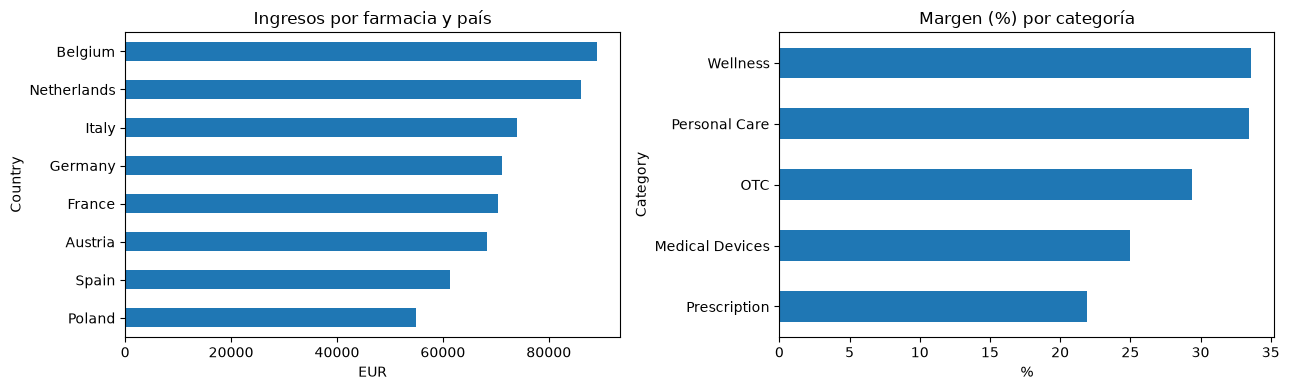

In [26]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
p1_pais["ingresos_por_farmacia"].sort_values().plot.barh(ax=ax[0], title="Ingresos por farmacia y país")
p1_cat["margen_pct"].sort_values().plot.barh(ax=ax[1], title="Margen (%) por categoría")
ax[0].set_xlabel("EUR")
ax[1].set_xlabel("%")
plt.tight_layout()
plt.show()

### Conclusión 1: Comparación del margen por farmacia entre países

- **Bélgica y Países Bajos** forman el grupo líder, con unos 24-25 k€ de margen por farmacia.
- **Polonia** ocupa la última posición, con 15,4 k€, un 38 % menos que Bélgica. Bélgica obtiene un margen por farmacia un 63 % superior (25.072 / 15.419 = 1,63).
- **Alemania lidera en margen total** (439 k€) debido a que cuenta con 22 farmacias. Sin embargo, su margen por farmacia se sitúa en la mitad inferior.
- **El margen porcentual apenas varía** entre países (del 27,8 % al 28,2 %). Por tanto, las diferencias se explican principalmente por el volumen de ventas por farmacia, y no por la rentabilidad de cada venta.

In [27]:
   print(pd.crosstab(data.drop_duplicates("PharmacyID")["Country"],
                     data.drop_duplicates("PharmacyID")["StoreSizeBand"], normalize="index").round(2))

StoreSizeBand     L     M     S
Country                        
Austria        0.20  0.50  0.30
Belgium        0.36  0.36  0.29
France         0.15  0.50  0.35
Germany        0.18  0.36  0.45
Italy          0.22  0.61  0.17
Netherlands    0.18  0.55  0.27
Poland         0.23  0.31  0.46
Spain          0.17  0.33  0.50


In [28]:
   print(data.groupby("Country").agg(ventas=("SalesID","count"),
         farmacias=("PharmacyID","nunique"),
         ingreso_medio=("RevenueEUR","mean")).assign(
         ventas_por_farmacia=lambda d: d["ventas"]/d["farmacias"]).round(1))

             ventas  farmacias  ingreso_medio  ventas_por_farmacia
Country                                                           
Austria        4693         10          145.6                469.3
Belgium        8280         14          150.5                591.4
France        10187         20          138.1                509.4
Germany       10628         22          147.5                483.1
Italy          9872         18          134.9                548.4
Netherlands    6138         11          154.4                558.0
Poland         6641         13          107.5                510.8
Spain          5700         12          129.1                475.0


In [29]:
print(pd.crosstab(data["Country"], data["Category"], values=data["RevenueEUR"],
                  aggfunc="sum", normalize="index").round(2))

Category     Medical Devices   OTC  Personal Care  Prescription  Wellness
Country                                                                  
Austria                 0.09  0.21           0.16          0.33      0.21
Belgium                 0.10  0.21           0.18          0.31      0.19
France                  0.10  0.21           0.16          0.33      0.20
Germany                 0.10  0.21           0.17          0.33      0.20
Italy                   0.11  0.21           0.17          0.32      0.20
Netherlands             0.10  0.21           0.17          0.33      0.19
Poland                  0.10  0.21           0.16          0.32      0.20
Spain                   0.10  0.20           0.16          0.34      0.20


**Pregunta 2 :¿Cómo evolucionan las ventas mes a mes y hay estacionalidad?**

In [19]:
p2 = data.groupby("YearMonth")["RevenueEUR"].sum().reset_index()
p2["Año"] = p2["YearMonth"].str[:4]
p2["Mes"] = p2["YearMonth"].str[5:7]
p2_tabla = p2.pivot(index="Mes", columns="Año", values="RevenueEUR")
p2_tabla.round(0)

Año,2024,2025
Mes,,
01,348141.0,345071.0
02,327319.0,329089.0
03,346367.0,354624.0
04,330369.0,355073.0
05,357867.0,392674.0
06,342538.0,379229.0
07,388334.0,380507.0
08,373988.0,367548.0
09,357305.0,373701.0


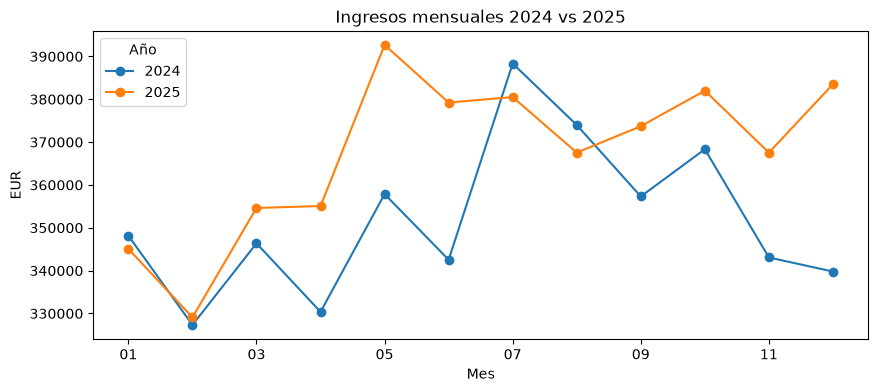

In [20]:
p2_tabla.plot(marker="o", figsize=(10, 4), title="Ingresos mensuales 2024 vs 2025")
plt.ylabel("EUR")
plt.xlabel("Mes")
plt.show()

Resultado: Mirando la grafica se observa que ha habido un aumento de ingresos en el año 2025, en la mayoria de meses excepto los meses 1,7,8

**Pregunta 3: promociones**

In [22]:
p3 = (
    data.groupby("PromoFlag")
    .agg(ventas=("SalesID", "count"),
         unidades_medias=("UnitsSold", "mean"),
         ingreso_medio=("RevenueEUR", "mean"),
         ingresos=("RevenueEUR", "sum"),
         margen=("MarginEUR", "sum"))
    .assign(margen_pct=lambda d: d["margen"] / d["ingresos"] * 100)
)
p3.round(2)

,ventas,unidades_medias,ingreso_medio,ingresos,margen,margen_pct
PromoFlag,,,,,,
No,54708,7.19,141.16,7722676.25,2239573.20,29.00
Yes,7431,7.02,122.64,911301.06,181567.87,19.92


Y el mismo calculo pero por categorias

In [23]:
p3_cat = (
    data.groupby(["Category", "PromoFlag"])
    .agg(unidades_medias=("UnitsSold", "mean"),
         ingresos=("RevenueEUR", "sum"),
         margen=("MarginEUR", "sum"))
    .assign(margen_pct=lambda d: d["margen"] / d["ingresos"] * 100)
    .round(2)
)
p3_cat

unidades_medias    ingresos     margen  margen_pct
Category        PromoFlag                                                    
Medical Devices No                    2.30   779619.95  202025.43       25.91
                Yes                   2.26    92952.02   15791.04       16.99
OTC             No                    9.17  1610572.58  487899.45       30.29
                Yes                   9.03   186756.97   40266.58       21.56
Personal Care   No                    9.22  1314042.81  450445.02       34.28
                Yes                   8.77   140560.34   36430.16       25.92
Prescription    No                    4.82  2484255.43  570116.78       22.95
                Yes                   4.84   312760.33   43049.61       13.76
Wellness        No                    7.18  1534185.48  529086.52       34.49
                Yes                   7.07   178271.40   46030.48       25.82

Resultado:El análisis muestra que las promociones reducen el margen porcentual en todas las categorías de productos. Wellness y Personal Care presentan los márgenes más altos cuando no hay promociones, con un 34,49 % y un 34,28 %, respectivamente. En cambio, Prescription es la categoría que genera más ingresos. Por tanto, sería conveniente revisar las promociones y comprobar si el aumento de ventas que puedan generar compensa la reducción del margen de beneficio.
